In [1]:
# --! include root folder into PYTHONPATH --!

import os
import sys

thisdir = os.getcwd()
rootdir = os.path.abspath(os.path.join(thisdir, '..', '..'))
sys.path.append(rootdir)

# --! import Python libraries --!

import numpy as np
import torch
from matplotlib import pyplot as plt

# --! import KIND framework files --!

import kind
import utils_data

In [2]:
# --! specify kind arguments --!

parser = kind.create_args_parser()

args = parser.parse_args(
    args=[
        '--dataset_id', 'kind-detuning-meas',
        '--file_dir', '../../data/kalman',
        '--file_name', 'tesla_meas',
        '--data_nsample', '144',
        '--feature_ndim', '3',
        '--target_ndim', '1',

        '--lookback_nsample', '96',
        '--forecast_nsample', '48',

        '--batch_size', '64',
        '--nepoch', '300',
        '--patience', '30',
        '--checkpoints', '../../models/kalman',

        '--seg_nsample_stat', '48',
        '--seg_nsample_trans', '12',
        '--fun_stat', '{"sin": 5, "cos": 5}',
        '--fun_trans', '{"sin": 5, "cos": 5}',
    ]
)


In [3]:
model = kind.model(args)
dataset = utils_data.dataset_factory().create_dataset(args)

In [4]:
model.train()
model.fit(dataset)

>>> train stationary mean >>>
	epoch 1 losses: train=1.826331, valid=0.565099, test=0.564569
	validation loss decreased (inf -> 0.565099), saving model ...
	epoch 2 losses: train=1.710673, valid=0.535625, test=0.530989
	validation loss decreased (0.565099 -> 0.535625), saving model ...
	epoch 3 losses: train=1.659854, valid=0.529077, test=0.526319
	validation loss decreased (0.535625 -> 0.529077), saving model ...
	epoch 4 losses: train=1.622627, valid=0.514889, test=0.514429
	validation loss decreased (0.529077 -> 0.514889), saving model ...
	epoch 5 losses: train=1.554680, valid=0.477229, test=0.473992
	validation loss decreased (0.514889 -> 0.477229), saving model ...
	epoch 6 losses: train=1.340302, valid=0.383123, test=0.374044
	validation loss decreased (0.477229 -> 0.383123), saving model ...
	epoch 7 losses: train=0.962870, valid=0.285259, test=0.276778
	validation loss decreased (0.383123 -> 0.285259), saving model ...
	epoch 8 losses: train=0.844715, valid=0.277663, test=0.26

In [5]:
model.eval()
_, _, data_loader = dataset.load(data_type='stat')

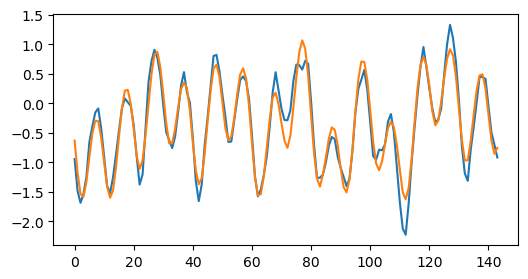

In [6]:
jdata = 9

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_output = model(back[[jdata]])
        stat = model_output[1]

        plt.figure(figsize=(6,3))
        plt.plot(truth[jdata, :, :1])
        plt.plot(stat[0, :, :1])
        plt.show()

        break

In [7]:
model.train()
model.fit_next()
model.fit(dataset)

>>> train stationary uncertainty >>>
	epoch 1 losses: train=0.565164, valid=0.428614, test=0.448754
	validation loss decreased (inf -> 0.428614), saving model ...
	epoch 2 losses: train=0.448258, valid=0.351624, test=0.372110
	validation loss decreased (0.428614 -> 0.351624), saving model ...
	epoch 3 losses: train=0.359508, valid=0.326657, test=0.342510
	validation loss decreased (0.351624 -> 0.326657), saving model ...
	epoch 4 losses: train=0.333329, valid=0.285483, test=0.308977
	validation loss decreased (0.326657 -> 0.285483), saving model ...
	epoch 5 losses: train=0.322766, valid=0.283154, test=0.301225
	validation loss decreased (0.285483 -> 0.283154), saving model ...
	epoch 6 losses: train=0.313923, valid=0.275158, test=0.294788
	validation loss decreased (0.283154 -> 0.275158), saving model ...
	epoch 7 losses: train=0.311715, valid=0.272713, test=0.291628
	validation loss decreased (0.275158 -> 0.272713), saving model ...
	epoch 8 losses: train=0.308580, valid=0.268935, te

In [8]:
model.eval()
_, _, data_loader = dataset.load(data_type='mixed')

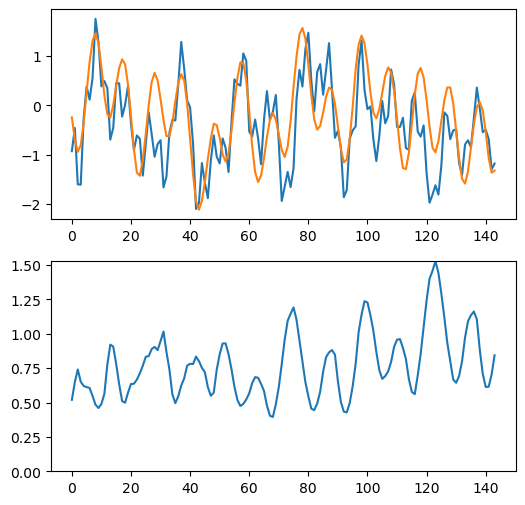

In [9]:
jdata = 10

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_output = model(back[[jdata]])
        stat = model_output[1]
        stat_uncertain = model_output[2]
        stat_uncertain = torch.exp(stat_uncertain) + 1e-6
        stat_uncertain_max = torch.max(stat_uncertain)
        stat_uncertain_max = 0.1 if stat_uncertain_max < 0.1 else stat_uncertain_max

        plt.figure(figsize=(6,6))

        plt.subplot(2,1,1)
        plt.plot(truth[jdata, :, :1])
        plt.plot(stat[0, :, :1])

        plt.subplot(2,1,2)
        plt.plot(stat_uncertain[0, :, :1])
        plt.ylim((0., stat_uncertain_max))

        plt.show()

        break

In [10]:
model.train()
model.fit_next()
model.fit(dataset)

>>> train transient mean >>>
	epoch 1 losses: train=1.666757, valid=1.177086, test=1.161688
	validation loss decreased (inf -> 1.177086), saving model ...
	epoch 2 losses: train=1.252017, valid=0.836024, test=0.820130
	validation loss decreased (1.177086 -> 0.836024), saving model ...
	epoch 3 losses: train=1.020631, valid=0.582989, test=0.569923
	validation loss decreased (0.836024 -> 0.582989), saving model ...
	epoch 4 losses: train=0.718842, valid=0.487033, test=0.476085
	validation loss decreased (0.582989 -> 0.487033), saving model ...
	epoch 5 losses: train=0.676437, valid=0.483484, test=0.474444
	validation loss decreased (0.487033 -> 0.483484), saving model ...
	epoch 6 losses: train=0.627717, valid=0.432516, test=0.420189
	validation loss decreased (0.483484 -> 0.432516), saving model ...
	epoch 7 losses: train=0.606377, valid=0.432720, test=0.419664
	early stopping counter: 1 out of 30
	epoch 8 losses: train=0.571842, valid=0.394725, test=0.384839
	validation loss decreased 

In [11]:
model.eval()
_, _, data_loader = dataset.load(data_type='mixed')

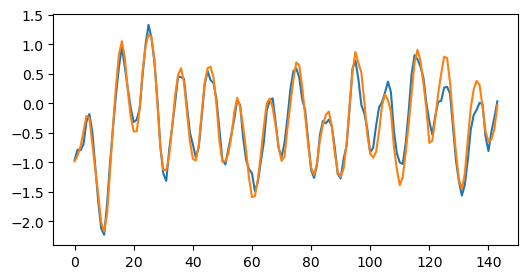

In [12]:
jdata = 21

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_output = model(back[[jdata]])
        trans = model_output[3]

        plt.figure(figsize=(6,3))
        plt.plot(truth[jdata, :, :1])
        plt.plot(trans[0, :, :1])

        plt.show()

        break

In [13]:
model.train()
model.fit_next()
model.fit(dataset)

>>> train transient uncertainty >>>
	epoch 1 losses: train=0.780193, valid=0.506035, test=0.514684
	validation loss decreased (inf -> 0.506035), saving model ...
	epoch 2 losses: train=0.168984, valid=0.084075, test=0.102300
	validation loss decreased (0.506035 -> 0.084075), saving model ...
	epoch 3 losses: train=0.009147, valid=0.067748, test=0.045020
	validation loss decreased (0.084075 -> 0.067748), saving model ...
	epoch 4 losses: train=-0.052646, valid=0.011603, test=0.014539
	validation loss decreased (0.067748 -> 0.011603), saving model ...
	epoch 5 losses: train=-0.099392, valid=0.060593, test=-0.028152
	early stopping counter: 1 out of 30
	epoch 6 losses: train=-0.148912, valid=-0.095785, test=-0.068928
	validation loss decreased (0.011603 -> -0.095785), saving model ...
	epoch 7 losses: train=-0.189920, valid=-0.123080, test=-0.095977
	validation loss decreased (-0.095785 -> -0.123080), saving model ...
	epoch 8 losses: train=-0.230782, valid=-0.148609, test=-0.124765
	vali

In [14]:
model.eval()
_, _, data_loader = dataset.load(data_type='mixed')

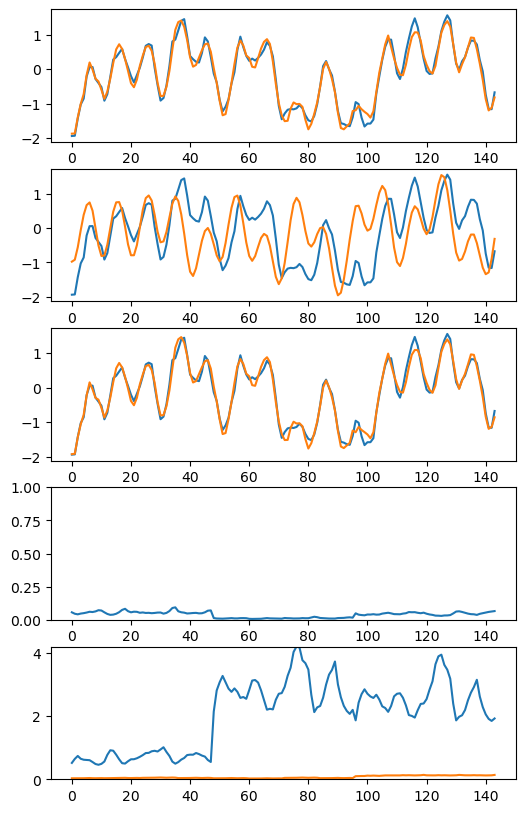

In [15]:
jdata = 30

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_output = model(back[[jdata]])
        blend = model_output[0]
        stat = model_output[1]
        trans = model_output[3]
        alpha = model_output[9]

        stat_uncertain = model_output[2]
        stat_uncertain = torch.exp(stat_uncertain) + 1e-6
        stat_uncertain_max = torch.max(stat_uncertain)
        stat_uncertain_max = 0.1 if stat_uncertain_max < 0.1 else stat_uncertain_max

        trans_uncertain = model_output[4]
        trans_uncertain = torch.exp(trans_uncertain) + 1e-6
        trans_uncertain_max = torch.max(trans_uncertain)
        trans_uncertain_max = 0.1 if trans_uncertain_max < 0.1 else trans_uncertain_max

        uncertain_max = stat_uncertain_max if stat_uncertain_max > trans_uncertain_max else trans_uncertain_max
        uncertain_max = 0.1 if uncertain_max < 0.1 else uncertain_max

        plt.figure(figsize=(6,10))

        plt.subplot(5,1,1)
        plt.plot(truth[jdata, :, :1])
        plt.plot(blend[0, :, :1])

        plt.subplot(5,1,2)
        plt.plot(truth[jdata, :, :1])
        plt.plot(stat[0, :, :1])

        plt.subplot(5,1,3)
        plt.plot(truth[jdata, :, :1])
        plt.plot(trans[0, :, :1])

        plt.subplot(5,1,4)
        plt.plot(alpha[0, :, :1])
        plt.ylim((0., 1.))

        plt.subplot(5,1,5)
        plt.plot(stat_uncertain[0,:,:1])
        plt.plot(trans_uncertain[0,:,:1])
        plt.ylim((0., uncertain_max))

        plt.show()

        break